<a href="https://colab.research.google.com/github/Sulac1-ui/AI-Lab/blob/main/Credit_Card_Fraud_Detection.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
import pandas as pd
import numpy as np

import seaborn as sns
import matplotlib.pyplot as plt
%matplotlib inline

import sys
import scipy
import sklearn
import kagglehub
import warnings
import os

In [3]:

# 1. Download the dataset
path = kagglehub.dataset_download("kartik2112/fraud-detection")
print("Path to dataset files:", path)

# 2. Define the file paths
train_path = os.path.join(path, "fraudTrain.csv")
test_path = os.path.join(path, "fraudTest.csv")

# 3. Load the data (Using a sample to save your 12GB RAM)
# We load the first 500,000 rows so Colab doesn't crash later
print("Loading data... please wait.")
df_train = pd.read_csv(train_path, index_col=0, nrows=500000)
df_test = pd.read_csv(test_path, index_col=0, nrows=100000)

# 4. Success Check
print("Data loaded successfully!")
print(f"Train set shape: {df_train.shape}")

# Now this will work!
df_train.head()

100%|██████████| 202M/202M [00:01<00:00, 158MB/s]

Extracting files...


Path to dataset files: /root/.cache/kagglehub/datasets/kartik2112/fraud-detection/versions/1
Loading data... please wait.
Data loaded successfully!
Train set shape: (500000, 22)


,trans_date_trans_time,cc_num,merchant,category,amt,first,last,gender,street,city,...,lat,long,city_pop,job,dob,trans_num,unix_time,merch_lat,merch_long,is_fraud
0,2019-01-01 00:00:18,2703186189652095,"fraud_Rippin, Kub and Mann",misc_net,4.97,Jennifer,Banks,F,561 Perry Cove,Moravian Falls,...,36.0788,-81.1781,3495,"Psychologist, counselling",1988-03-09,0b242abb623afc578575680df30655b9,1325376018,36.011293,-82.048315,0
1,2019-01-01 00:00:44,630423337322,"fraud_Heller, Gutmann and Zieme",grocery_pos,107.23,Stephanie,Gill,F,43039 Riley Greens Suite 393,Orient,...,48.8878,-118.2105,149,Special educational needs teacher,1978-06-21,1f76529f8574734946361c461b024d99,1325376044,49.159047,-118.186462,0
2,2019-01-01 00:00:51,38859492057661,fraud_Lind-Buckridge,entertainment,220.11,Edward,Sanchez,M,594 White Dale Suite 530,Malad City,...,42.1808,-112.2620,4154,Nature conservation officer,1962-01-19,a1a22d70485983eac12b5b88dad1cf95,1325376051,43.150704,-112.154481,0
3,2019-01-01 00:01:16,3534093764340240,"fraud_Kutch, Hermiston and Farrell",gas_transport,45.00,Jeremy,White,M,9443 Cynthia Court Apt. 038,Boulder,...,46.2306,-112.1138,1939,Patent attorney,1967-01-12,6b849c168bdad6f867558c3793159a81,1325376076,47.034331,-112.561071,0
4,2019-01-01 00:03:06,375534208663984,fraud_Keeling-Crist,misc_pos,41.96,Tyler,Garcia,M,408 Bradley Rest,Doe Hill,...,38.4207,-79.4629,99,Dance movement psychotherapist,1986-03-28,a41d7549acf90789359a9aa5346dcb46,1325376186,38.674999,-78.632459,0


In [4]:
df_full = pd.concat([df_train, df_test], axis=0)

In [5]:
df_full.shape

(600000, 22)

In [6]:
display(df_full.describe().T)

,count,mean,std,min,25%,50%,75%,max
cc_num,600000.0,4.161056e+17,1.307230e+18,6.041621e+10,1.800365e+14,3.519607e+15,4.635331e+15,4.992346e+18
amt,600000.0,7.027438e+01,1.582195e+02,1.000000e+00,9.650000e+00,4.751000e+01,8.323000e+01,2.508694e+04
zip,600000.0,4.876536e+04,2.690019e+04,1.257000e+03,2.604100e+04,4.817400e+04,7.201100e+04,9.978300e+04
lat,600000.0,3.853740e+01,5.072827e+00,2.002710e+01,3.466890e+01,3.935430e+01,4.194040e+01,6.669330e+01
long,600000.0,-9.020424e+01,1.375414e+01,-1.656723e+02,-9.679800e+01,-8.745810e+01,-8.015800e+01,-6.795030e+01
city_pop,600000.0,8.912193e+04,3.029706e+05,2.300000e+01,7.430000e+02,2.456000e+03,2.032800e+04,2.906700e+06
unix_time,600000.0,1.342001e+09,1.481800e+07,1.325376e+09,1.332390e+09,1.338049e+09,1.342687e+09,1.374844e+09
merch_lat,600000.0,3.853659e+01,5.107053e+00,1.902980e+01,3.474283e+01,3.936458e+01,4.195730e+01,6.751027e+01
merch_long,600000.0,-9.020430e+01,1.376653e+01,-1.666712e+02,-9.687670e+01,-8.740926e+01,-8.021422e+01,-6.695235e+01
is_fraud,600000.0,5.738333e-03,7.553419e-02,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,1.000000e+00


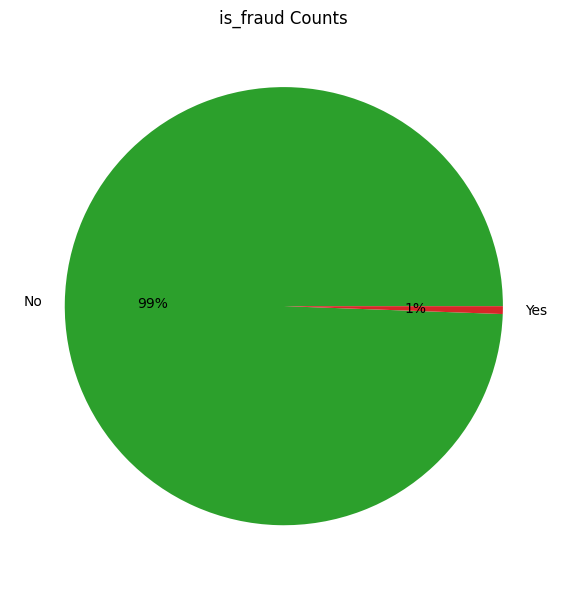

In [7]:
counts = df_full["is_fraud"].value_counts()
plt.figure(figsize=(12, 6))
plt.pie(counts, labels=["No", "Yes"], colors=['tab:green', 'tab:red'], autopct="%0.0f%%")
plt.title("is_fraud Counts")
plt.tight_layout()  # Adjust layout to prevent overlapping
plt.show()

In [8]:
df_full['trans_date_trans_time'] = pd.to_datetime(df_full['trans_date_trans_time'])
df_full['dob'] = pd.to_datetime(df_full['dob'])
df_full = df_full.drop(['Unnamed: 0'], axis=1, errors='ignore')

In [9]:
# Hour of transaction (help for model to recognize if it was during day or during night)
df_full['hour'] = df_full['trans_date_trans_time'].dt.hour

# Day of week ot the  transaction (help for model to recognize if it was regular day or weeend)
df_full['day_of_week'] = df_full['trans_date_trans_time'].dt.dayofweek

# Age of client instead of date of birth - it is more useful for categorization of for groups of age
df_full['age'] = (df_full['trans_date_trans_time'] - df_full['dob']).dt.days // 365

In [10]:
df_full.sample(10)

,trans_date_trans_time,cc_num,merchant,category,amt,first,last,gender,street,city,...,job,dob,trans_num,unix_time,merch_lat,merch_long,is_fraud,hour,day_of_week,age
10536,2019-01-07 10:58:56,377654590313960,"fraud_Jenkins, Hauck and Friesen",gas_transport,63.90,Lawrence,Davis,M,7421 Serrano Lane Apt. 580,Powell,...,"Teacher, special educational needs",1969-02-22,b5cefc13730a1eb4376073be4eca2a12,1325933936,36.150268,-83.771132,0,10,0,49
398422,2019-06-30 16:17:10,4687263141103,"fraud_Daugherty, Pouros and Beahan",shopping_pos,4.39,Sarah,Cross,F,273 Phillip Throughway,Bigelow,...,Economist,1977-04-28,b0ee0e988a2a02cf166c6688c957fb45,1341073030,44.153073,-96.187882,0,16,6,42
308002,2019-05-29 12:17:34,4425161475596168,"fraud_Pouros, Walker and Spencer",kids_pets,45.27,Brooke,Fisher,F,815 Heather Divide Apt. 965,San Angelo,...,Drilling engineer,1962-06-27,605d90bbeaeb76c55624f0373795eba9,1338293854,30.537147,-100.902225,0,12,2,56
247221,2019-05-04 06:38:45,375974680629816,fraud_Kiehn-Emmerich,grocery_pos,114.88,Roberta,Mccarthy,F,94431 Matthew Mall Suite 296,Plymouth,...,Herpetologist,1973-04-06,214f7434ca0899cac1727871f61e86c6,1336113525,41.209372,-72.279699,0,6,5,46
352912,2019-06-14 20:22:17,3596357274378601,fraud_Abshire PLC,entertainment,28.51,David,Everett,M,4138 David Fall,Morrisdale,...,Advice worker,1973-05-27,23247fcc8e9bb8a7162a70de67d646d8,1339705337,40.036311,-77.549877,0,20,4,46
73914,2020-07-16 23:50:38,30074693890476,fraud_Kuhn LLC,shopping_pos,6.99,Kelsey,Richards,F,889 Sarah Station Suite 624,Holcomb,...,Arboriculturist,1993-08-16,9cb007b6d911207ac39bbaad174e2578,1374018638,37.952044,-100.908830,0,23,3,26
272880,2019-05-15 00:21:16,345389171551808,fraud_Huels-Hahn,gas_transport,54.05,Justin,Fowler,M,5569 Phillips Neck Apt. 003,Coffeeville,...,Financial trader,1984-05-19,44e9b4ba4fd0d4a8f8c3d980ce74ac1e,1337041276,34.394178,-90.133146,0,0,2,35
144073,2019-03-18 19:46:37,3523898249167098,fraud_McDermott-Rice,misc_pos,8.21,Joshua,Carpenter,M,04975 Allison Shoal,Bronx,...,"Therapist, drama",1990-11-09,ef76766c1602baddd3d9358f14d82867,1332099997,40.593116,-73.254238,0,19,0,28
370809,2019-06-20 23:53:00,213186334552049,fraud_Ratke and Sons,health_fitness,60.24,Andrea,Perkins,F,37426 Olson Villages,Irvine,...,Chief Marketing Officer,1972-09-13,91044b2e49acdb385de06131458985bc,1340236380,42.166675,-80.063288,0,23,3,46
413913,2019-07-06 13:32:16,376028110684021,fraud_Kilback Group,food_dining,54.75,Aaron,Murray,M,624 Hale Springs Apt. 572,Meadville,...,Tourist information centre manager,1974-12-23,07fd2aaec1d227cb3a4a507fae530090,1341581536,39.765693,-92.514769,0,13,5,44


In [11]:
# We are picking only the features that have 'patterns'
# (e.g., Fraudsters target certain categories or age groups)
important_columns = [
    'category', 'amt', 'gender', 'job', 'city_pop',
    'lat', 'long', 'merch_lat', 'merch_long',
    'hour', 'day_of_week', 'age', 'is_fraud', 'cc_num', 'trans_date_trans_time'
]

df_full= df_full[important_columns]

In [12]:
# Let's check how it looks now
print("New Shape:", df_full.shape)
df_full.head()

New Shape: (600000, 15)


,category,amt,gender,job,city_pop,lat,long,merch_lat,merch_long,hour,day_of_week,age,is_fraud,cc_num,trans_date_trans_time
0,misc_net,4.97,F,"Psychologist, counselling",3495,36.0788,-81.1781,36.011293,-82.048315,0,1,30,0,2703186189652095,2019-01-01 00:00:18
1,grocery_pos,107.23,F,Special educational needs teacher,149,48.8878,-118.2105,49.159047,-118.186462,0,1,40,0,630423337322,2019-01-01 00:00:44
2,entertainment,220.11,M,Nature conservation officer,4154,42.1808,-112.2620,43.150704,-112.154481,0,1,56,0,38859492057661,2019-01-01 00:00:51
3,gas_transport,45.00,M,Patent attorney,1939,46.2306,-112.1138,47.034331,-112.561071,0,1,52,0,3534093764340240,2019-01-01 00:01:16
4,misc_pos,41.96,M,Dance movement psychotherapist,99,38.4207,-79.4629,38.674999,-78.632459,0,1,32,0,375534208663984,2019-01-01 00:03:06


# Why did we pick these?
* amt: Fraud usually involves unusual amounts.

* category: Some categories (like "online_retail") have higher fraud than others.

* hour & day_of_week: Fraud often happens late at night.

* age: Fraudsters often target specific age demographics.

* lat/long: Location helps find "impossible travel" (e.g., a card used in Nepal and New York in the same hour).




**n fraud detection, this is known as Spatial Analysis. If a customer lives in Kathmandu but a transaction happens 500km away at a merchant in a different province within minutes, that's a huge "red flag."**

# **The Haversine formula calculates the "great-circle" distance between two points on a sphere (Earth) using their longitudes and latitudes.**

In [13]:
def calculate_haversine(df):
    """
    Calculates the distance (in km) between the customer and the merchant.
    """
    # Earth's radius in kilometers
    R = 6371.0

    # Convert degrees to radians
    lat1, lon1 = np.radians(df['lat']), np.radians(df['long'])
    lat2, lon2 = np.radians(df['merch_lat']), np.radians(df['merch_long'])

    # Differences
    dlat = lat2 - lat1
    dlon = lon2 - lon1

    # Haversine formula
    a = np.sin(dlat / 2)**2 + np.cos(lat1) * np.cos(lat2) * np.sin(dlon / 2)**2
    c = 2 * np.arctan2(np.sqrt(a), np.sqrt(1 - a))

    # Add the result to the dataframe
    df['distance_km'] = R * c
    return df

In [14]:
# Apply the function
df_full = calculate_haversine(df_full)

# Let's see the results
print("Distance calculation complete!")
print(df_full[['lat', 'long', 'merch_lat', 'merch_long', 'distance_km']].head())

Distance calculation complete!
       lat      long  merch_lat  merch_long  distance_km
0  36.0788  -81.1781  36.011293  -82.048315    78.597568
1  48.8878 -118.2105  49.159047 -118.186462    30.212176
2  42.1808 -112.2620  43.150704 -112.154481   108.206083
3  46.2306 -112.1138  47.034331 -112.561071    95.673231
4  38.4207  -79.4629  38.674999  -78.632459    77.556744


In [15]:
df_full.columns

Index(['category', 'amt', 'gender', 'job', 'city_pop', 'lat', 'long',
       'merch_lat', 'merch_long', 'hour', 'day_of_week', 'age', 'is_fraud',
       'cc_num', 'trans_date_trans_time', 'distance_km'],
      dtype='object')

# If the distance_km is very high (e.g., > 100km), it doesn't always mean fraud, but when combined with the hour of the transaction, it becomes a powerful predictor.

**Here average distance calculation of fraud and non-fraud is 76km approx. Solely depending upon distance we cannot predict the Fraud Case.**

In [16]:
print(df_full.groupby('is_fraud')['distance_km'].mean())

is_fraud
0    76.132031
1    75.901414
Name: distance_km, dtype: float64


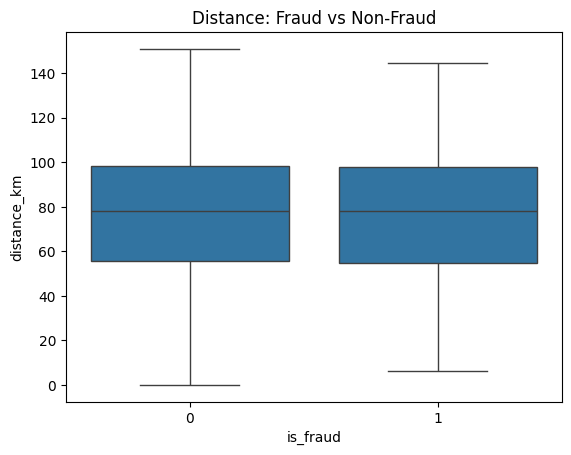

In [17]:
sns.boxplot(x='is_fraud', y='distance_km', data=df_full.sample(200000))
plt.title("Distance: Fraud vs Non-Fraud")
plt.show()

# Now that we have distance_km, the raw latitude and longitude coordinates are like keeping the "ingredients list" after you’ve already baked the cake. Let's remove them to focus the model on the meaningful features.

In [18]:
# Drop the raw coordinate columns
cols_to_drop = ['lat', 'long', 'merch_lat', 'merch_long']
df_full = df_full.drop(columns=cols_to_drop)

print("Redundant columns removed. Current feature list:")
print(df_full.columns.tolist())

Redundant columns removed. Current feature list:
['category', 'amt', 'gender', 'job', 'city_pop', 'hour', 'day_of_week', 'age', 'is_fraud', 'cc_num', 'trans_date_trans_time', 'distance_km']


In [19]:

df_full['avg_amt_user'] = df_full.groupby('cc_num')['amt'].transform('mean')

df_full['amt_vs_avg'] = df_full['amt'] / df_full['avg_amt_user']

In [20]:
df_full[df_full['amt_vs_avg']>10]

,category,amt,gender,job,city_pop,hour,day_of_week,age,is_fraud,cc_num,trans_date_trans_time,distance_km,avg_amt_user,amt_vs_avg
232,shopping_net,1055.47,M,Community arts worker,648,2,1,49,0,4311368326621416041,2019-01-01 02:54:10,99.127145,60.503231,17.444853
296,shopping_net,909.66,F,Engineering geologist,736284,3,1,66,0,571844099986,2019-01-01 03:51:28,104.132972,71.417090,12.737287
511,misc_net,1636.87,F,"Engineer, technical sales",1324,6,1,92,0,4509142395811241,2019-01-01 06:43:54,89.832164,64.443170,25.400209
723,misc_net,1047.52,F,"Physicist, medical",969,9,1,65,0,4265776278887457,2019-01-01 09:23:55,51.730158,69.815689,15.004077
764,shopping_pos,658.55,M,Equities trader,47772,9,1,53,0,5501083170975659,2019-01-01 09:51:52,123.681151,63.686700,10.340464
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
99233,misc_net,819.50,F,Biomedical scientist,2206,6,6,33,0,4294040533480516,2020-07-26 06:43:47,57.367678,55.416144,14.788109
99686,misc_net,687.63,F,"Engineer, production",43,10,6,70,0,4128730454058057622,2020-07-26 10:46:20,81.933276,63.742516,10.787619
99825,shopping_pos,1074.88,M,Travel agency manager,17867,12,6,22,0,3567697931646329,2020-07-26 12:02:40,122.609598,51.894566,20.712766
99975,shopping_net,747.31,F,Energy engineer,1970,12,6,34,0,6011104316292105,2020-07-26 12:53:46,91.218375,55.833430,13.384634


In [21]:
# (night) HOURs + (higher)AMOUNT/AVERAGE USER AMOUNT = feature'night_high_spend'

# overnight transaction and a much larger amount than usual suggest fraud (very effective)

df_full['night_high_spend'] = ((df_full['hour'] < 6) & (df_full['amt_vs_avg'] > 2)).astype(int)


* **(df['hour'] < 6)**: This targets the "Dead of Night" (Midnight to 6:00 AM). Statistically, most legitimate retail transactions happen when people are awake.

* **(df['amt_vs_avg'] > 2**): This targets "High Deviation." It flags any transaction that is more than double what that specific user usually spends.

* **.astype(int):** This turns a "True" into a 1 and a "False" into a 0.

In [22]:
df_full['Far_and_expensive']=((df_full['distance_km']>100) & (df_full['amt_vs_avg']>2)).astype(int)

# **For every single transaction, the model looks back exactly 24 hours and counts how many other transactions it sees in that "light." If it sees 1, it's normal. If it sees 20, it's a major fraud signal.**

In [23]:
# 1. Make sure the time column is in the right format
df_full['trans_date_trans_time'] = pd.to_datetime(df_full['trans_date_trans_time'])

# 2. Sort the data by time (Time windows MUST be sorted to work)
df_full = df_full.sort_values(by='trans_date_trans_time')

# 3. Calculate the 24-hour rolling count
# We tell Pandas: "Group by card, look at a 24h window of the time column, and count the amounts"
df_full['trans_count_24h'] = (
    df_full.groupby('cc_num')
    .rolling('24h', on='trans_date_trans_time')['amt']
    .count()
    .values
)

print("Velocity feature 'trans_count_24h' created successfully!")
df_full[['cc_num', 'trans_date_trans_time', 'trans_count_24h']].head()

Velocity feature 'trans_count_24h' created successfully!


,cc_num,trans_date_trans_time,trans_count_24h
0,2703186189652095,2019-01-01 00:00:18,1.0
1,630423337322,2019-01-01 00:00:44,2.0
2,38859492057661,2019-01-01 00:00:51,3.0
3,3534093764340240,2019-01-01 00:01:16,4.0
4,375534208663984,2019-01-01 00:03:06,4.0


In [24]:
print(df_full.groupby('is_fraud')['night_high_spend'].mean())
print(df_full.groupby('is_fraud')['Far_and_expensive'].mean())

is_fraud
0    0.023051
1    0.226837
Name: night_high_spend, dtype: float64
is_fraud
0    0.023237
1    0.158583
Name: Far_and_expensive, dtype: float64


# **Here night_high_spend is 2.2% for normal transactions however 22.2% is for fraudalent transactions. which is 10X more and, also Far and expensive is 2.2% for normal transaction and 15.85% for fraudalent transactions which is almost 7-8X more**

In [25]:
# 1. Create a raw score by multiplying our two "Red Flags"
# We add +1 to avoid issues with zeros
df_full['raw_risk'] = df_full['distance_km'] * df_full['amt_vs_avg']

# 2. Use Log scaling to keep the numbers reasonable
# This turns a massive range into a smaller, more manageable scale
df_full['risk_score'] = np.log1p(df_full['raw_risk'])

# 3. Optional: Scale it from 0 to 100 to make it look like a professional credit score
from sklearn.preprocessing import MinMaxScaler
scaler = MinMaxScaler(feature_range=(0, 100))
df_full['risk_score'] = scaler.fit_transform(df_full[['risk_score']])

print("Risk Score created!")
df_full[['distance_km', 'amt_vs_avg', 'risk_score']].head()

Risk Score created!


,distance_km,amt_vs_avg,risk_score
0,78.597568,0.054789,16.778199
1,30.212176,1.725742,40.080904
2,108.206083,3.309539,59.405981
3,95.673231,0.727053,42.948780
4,77.556744,0.415669,35.335343


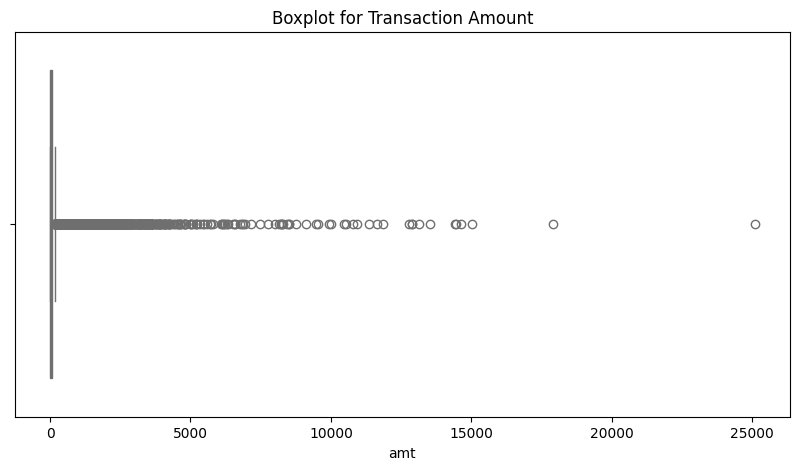

In [26]:
import seaborn as sns
import matplotlib.pyplot as plt

# Let's check outliers for the 'amt' column
plt.figure(figsize=(10, 5))
sns.boxplot(x=df_full['amt'], color='skyblue')
plt.title('Boxplot for Transaction Amount')
plt.show()

In [27]:
def detect_outliers_iqr(df, column):
    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)
    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    # Identify the outliers
    outliers = df[(df[column] < lower_bound) | (df[column] > upper_bound)]

    print(f"--- Outlier Report for {column} ---")
    print(f"IQR: {IQR}")
    print(f"Lower Bound: {lower_bound}")
    print(f"Upper Bound: {upper_bound}")
    print(f"Total Outliers detected: {len(outliers)}")
    print(f"Percentage of outliers: {len(outliers)/len(df)*100:.2f}%")

    return outliers

# Run it on your amount column
amt_outliers = detect_outliers_iqr(df_full, ['amt','distance_km'])

--- Outlier Report for ['amt', 'distance_km'] ---
IQR: amt            73.580000
distance_km    43.131653
dtype: float64
Lower Bound: amt           -100.720000
distance_km     -9.320587
dtype: float64
Upper Bound: amt            193.600000
distance_km    163.206023
dtype: float64
Total Outliers detected: 600000
Percentage of outliers: 100.00%


In [28]:
final_features= [
    'amt', 'city_pop', 'hour', 'day_of_week', 'age',
    'distance_km', 'amt_vs_avg', 'night_high_spend',
    'trans_count_24h', 'risk_score'
]

In [29]:
X= df_full[final_features]
y= df_full['is_fraud']

In [30]:
from sklearn.model_selection import train_test_split

In [31]:
# STEP 1: Split into Training (80%) and a Temporary set (20%)
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# STEP 2: Split that Temporary set into Validation and Test
# Using test_size=0.5 here gives you 10% for Val and 10% for Test
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.5, random_state=42, stratify=y_temp
)

In [32]:
def check_balance(y, set_name):
    count = y.value_counts()
    percent = y.value_counts(normalize=True) * 100
    print(f"--- {set_name} Set ---")
    print(f"Total Samples: {len(y)}")
    print(f"Legit (0): {count[0]} ({percent[0]:.4f}%)")
    print(f"Fraud (1): {count[1]} ({percent[1]:.4f}%)")
    print("-" * 25)

# Check all three
check_balance(y_train, "Training")
check_balance(y_val, "Validation")
check_balance(y_test, "Testing")

--- Training Set ---
Total Samples: 480000
Legit (0): 477246 (99.4263%)
Fraud (1): 2754 (0.5738%)
-------------------------
--- Validation Set ---
Total Samples: 60000
Legit (0): 59655 (99.4250%)
Fraud (1): 345 (0.5750%)
-------------------------
--- Testing Set ---
Total Samples: 60000
Legit (0): 59656 (99.4267%)
Fraud (1): 344 (0.5733%)
-------------------------


# **Applying SMOTE only to X_train. Your Validation and Test sets must remain "pure" and imbalanced, just like the real world.**

In [33]:
from imblearn.over_sampling import SMOTE

# 1. Initialize SMOTE
# We use a random_state so our results are reproducible
smote = SMOTE(random_state=42)

# 2. Resample ONLY the training data
print("Synthesizing fraud cases... please wait.")
X_train_res, y_train_res = smote.fit_resample(X_train, y_train)

# 3. Verify the new balance
print("\n--- Training Set After SMOTE ---")
print(f"Total rows: {len(y_train_res)}")
print(f"Fraud cases: {sum(y_train_res == 1)}")
print(f"Legit cases: {sum(y_train_res == 0)}")

Synthesizing fraud cases... please wait.

--- Training Set After SMOTE ---
Total rows: 954492
Fraud cases: 477246
Legit cases: 477246


In [34]:
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.metrics import recall_score, precision_score, average_precision_score
import time

# 1. Baseline Random Forest
rf_base = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
rf_base.fit(X_train, y_train)

# 2. Baseline XGBoost
# We use scale_pos_weight to help XGBoost see the rare fraud cases immediately
# ratio = float(y_train.value_counts()[0] / y_train.value_counts()[1])
# xgb_base = XGBClassifier(n_estimators=100, scale_pos_weight=ratio, random_state=42, n_jobs=-1)
# xgb_base.fit(X_train, y_train)

print("✅ Baseline models trained.")

✅ Baseline models trained.


In [35]:
importance = pd.DataFrame({
    'feature': final_features,
    'importance': rf_base.feature_importances_
}).sort_values(by='importance', ascending=False)

print(importance)

            feature  importance
0               amt    0.270810
6        amt_vs_avg    0.173386
2              hour    0.141282
9        risk_score    0.099696
4               age    0.097500
1          city_pop    0.077895
5       distance_km    0.067865
8   trans_count_24h    0.031114
3       day_of_week    0.024844
7  night_high_spend    0.015608


* amt: Simply put, fraud often involves higher dollar amounts because criminals want to maximize their "haul" before a card is frozen.
* amt_vs_avg: It measures the deviation from the norm. A $200 transaction might be normal for one person but highly suspicious for another.The model is essentially looking foR.
* hour: Criminals often test cards or make large purchases late at night or during early morning hours when users are asleep and less likely to notice an SMS alert.

* risk_score: This confirms that the interaction between distance and spending amount is a meaningful predictor. It captures the "Traveling Fraudster" pattern perfectly.

In [45]:
y_test= rf_base.predict(X_test)

In [47]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00     59771
           1       0.77      1.00      0.87       229

    accuracy                           1.00     60000
   macro avg       0.89      1.00      0.94     60000
weighted avg       1.00      1.00      1.00     60000



* precision (how many predicted frauds are actually fraud — reflects how many false alarms you generate for legitimate customers)
* recall (how many real frauds were correctly detected — shows how many fraudulent transactions you successfully catch)
* f1-score (balance between precision and recall — represents the trade-off between catching frauds and avoiding false alarms)
* support (number of true samples for each class — indicates how imbalanced the dataset is, with far fewer fraud cases)

In [41]:
y_prob = rf_base.predict_proba(X_test)[:,1]

y_pred = (y_prob > 0.3).astype(int)

In [38]:
y_probs_xgb = rf_base.predict_proba(X_test)[:, 1]

# 2. Calculate the Average Precision Score
ap_rf = average_precision_score(y_test, y_probs_xgb)

print(f"Random Forest Average Precision: {ap_rf:.4f}")

Random Forest Average Precision: 0.7370


Why AP is Calculated This WayThe formula for Average Precision is:$$AP = \sum_{n}(R_n - R_{n-1}) P_n$$Where $P_n$ and $R_n$ are the precision and recall at the $n^{th}$ threshold. Essentially, it calculates the area under the Precision-Recall Curve.

In [43]:
from sklearn.metrics import classification_report
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00     59656
           1       0.77      0.67      0.71       344

    accuracy                           1.00     60000
   macro avg       0.88      0.83      0.86     60000
weighted avg       1.00      1.00      1.00     60000

